In [44]:
%reset -f

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt  
from matplotlib import colors as mcolors
from matplotlib.patches import FancyArrowPatch
import seaborn as sns
import warnings
from scipy.optimize import curve_fit
warnings.filterwarnings('ignore')

pd.set_option('mode.chained_assignment', None)


root_dir = '/Users/weiweizhan/Desktop/Weiwei_Zhan/Projects/WUE'

os.chdir(root_dir)

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [2]:
df_site    = pd.read_csv('./Data/results/sites_meta_info.csv',index_col=0)

df_SNR     = pd.read_csv('./Data/results/beta_SNR_results.csv',index_col=0)

df_delta_Y = pd.read_csv('./Data/results/delta_Y_CO2_results.csv',index_col=0)

## Fig. 2: pie chart & beta distribution

In [3]:
blue_c   = '#0072B2'
brown_c  = '#E69F00'
green_c  = '#009E73'

order_gen = ['detectable','non-detectable']
color_dic = {'Gc':blue_c,'GPP':brown_c,'iWUE':green_c,'Gs':blue_c}

In [4]:
beta_values = {
    'Gc': df_SNR['Gc_beta'].values,
    'GPP': df_SNR['GPP_beta'].values,
    'iWUE': df_SNR['iWUE_beta'].values
}

data = [beta_values['GPP'], beta_values['Gc'], beta_values['iWUE']]

# Converting the data into a DataFrame for use with seaborn
data = pd.DataFrame(beta_values)

# Melt the DataFrame for easier plotting
melted_data = data.melt(var_name='Variable', 
                        value_name='Beta Value')


In [5]:
fontsize = 6.5

plt.rcParams["legend.frameon"] = False
plt.rcParams['savefig.dpi'] = 800
plt.rcParams['font.size'] = fontsize
plt.rcParams['font.family'] = 'Arial'

In [6]:
def pie_chart(data,fig,ax,colors,startangle,order_gen,a,b,fontsize=fontsize):

    wedges, texts,_ = ax.pie(data,autopct=lambda x: '{:.0f}'.format(x*df_SNR.shape[0]/100),
                             wedgeprops={"alpha": 1,"edgecolor" : "none",'linewidth': 0.5,'antialiased': True},
                             textprops={'size': fontsize,'weight':'bold'},colors=colors,startangle=startangle)
    
    bbox_props = dict(boxstyle="square,pad=0.3", fc="w", ec="none")
    kw = dict(arrowprops=dict(arrowstyle="-",lw=0.5),
              bbox=bbox_props, zorder=0, va="center",fontsize=fontsize)
    
    for i, p in enumerate(wedges):
        
        ang = (p.theta2 - p.theta1)/2. + p.theta1
        y = np.sin(np.deg2rad(ang))
        x = np.cos(np.deg2rad(ang))
        horizontalalignment = {-1: "right", 1: "left"}[int(np.sign(x))]
        connectionstyle = f"angle,angleA=0,angleB={ang}"
        kw["arrowprops"].update({"connectionstyle": connectionstyle})
        ax.annotate(order_gen[i], xy=(x, y), xytext=(a*np.sign(x), b*y),
                    horizontalalignment=horizontalalignment, **kw)


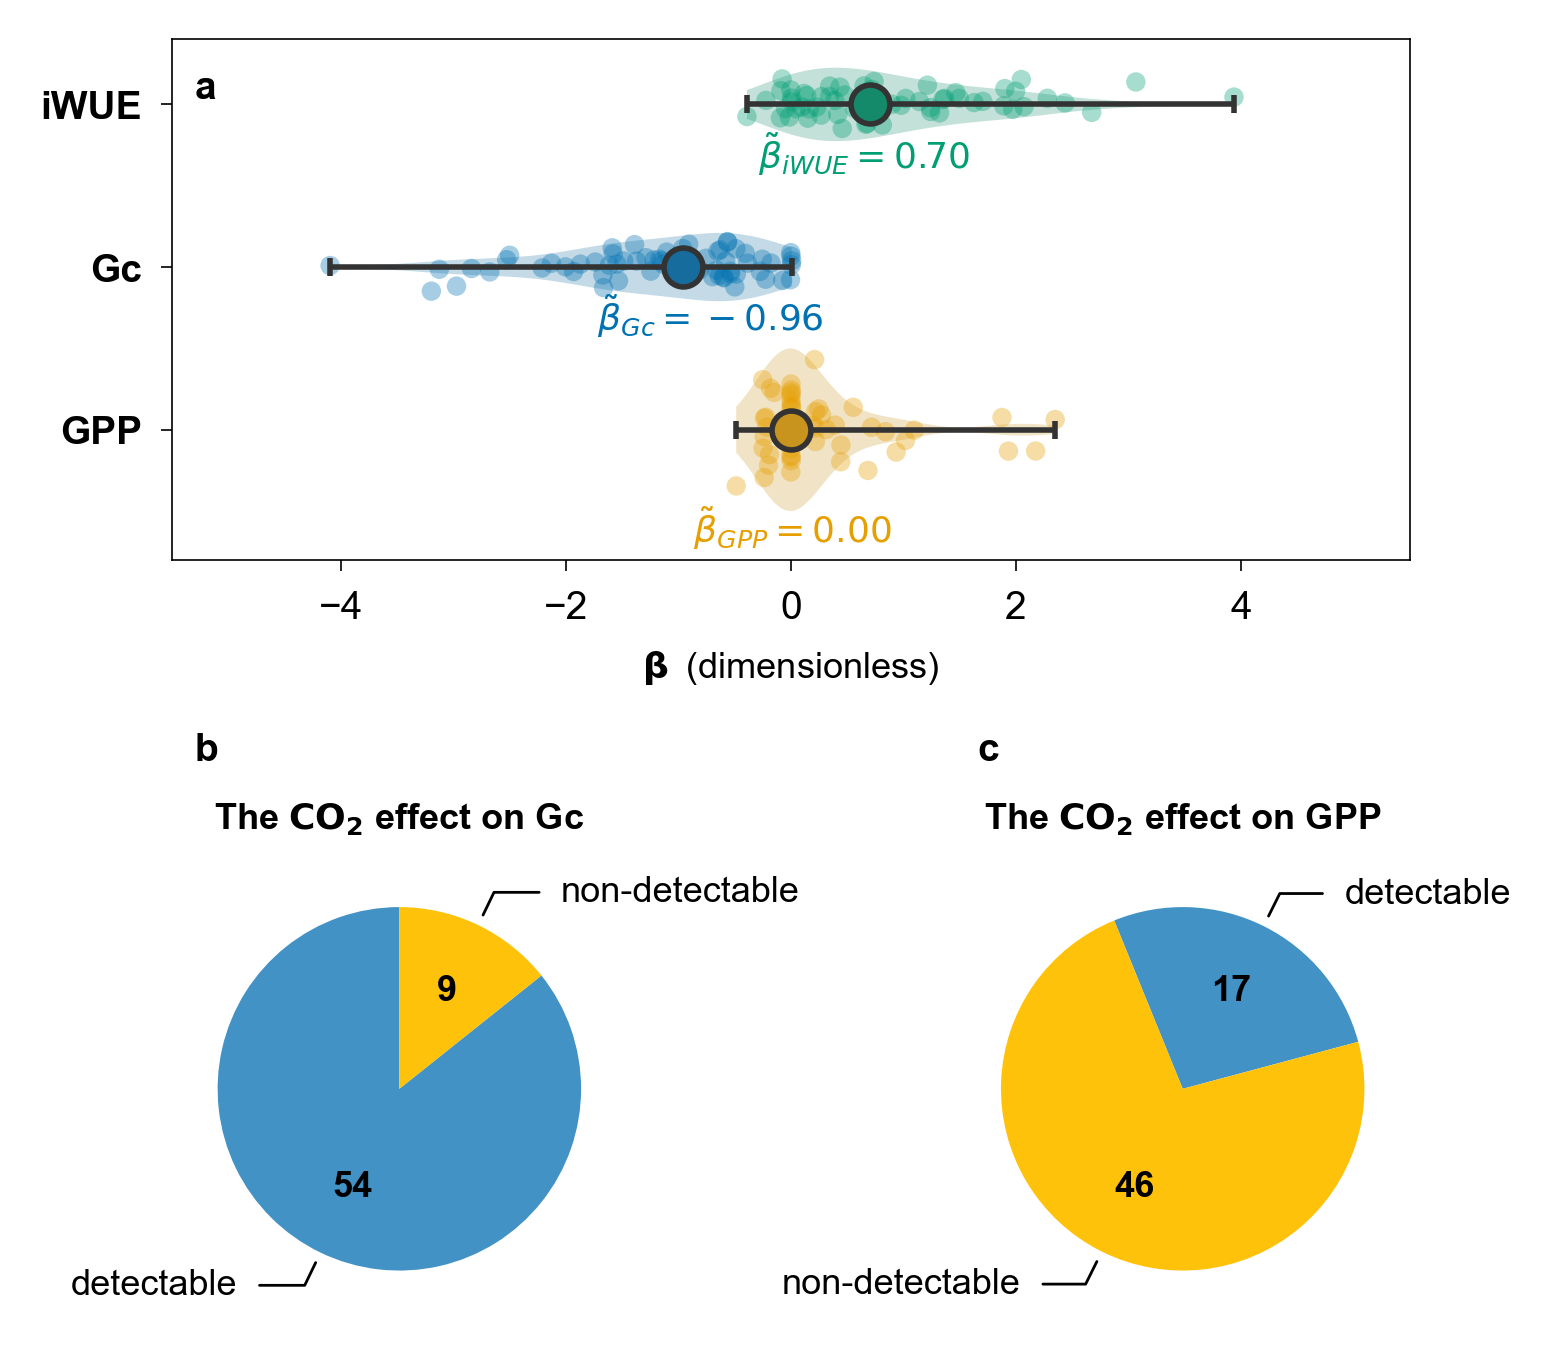

In [ ]:
width_old, height_old = 8.2, 7.5 # inches
width_new   = 3.8
height_new  = height_old/width_old*width_new

fig = plt.figure(figsize=(width_new,height_new),dpi=200)

shape    = (2,2)
ax_1 = plt.subplot2grid(shape, loc=(0,0), colspan=2,rowspan=1)
ax_2 = plt.subplot2grid(shape, loc=(1,0), colspan=1,rowspan=1)
ax_3 = plt.subplot2grid(shape, loc=(1,1), colspan=1,rowspan=1)

# pie chart
blue_pie, red_pie = '#4292C5','#FFC20A'#
df_group = df_SNR.groupby('Gc_cluster').count().mode(axis=1).iloc[:,0]
data     = df_group.loc[order_gen].values
pie_chart(data,fig,ax_2,[blue_pie, red_pie],90,order_gen,0.89,1.2)


df_group = df_SNR.groupby('GPP_cluster').count().mode(axis=1).iloc[:,0]
data     = df_group.loc[order_gen].values
pie_chart(data,fig,ax_3,[blue_pie, red_pie],15,order_gen,0.89,1.2)


targets = ['Gc','GPP']
for i,ax in enumerate([ax_2,ax_3]):
    ax.set_ylabel('')
    ax.set_title(f'The $\\mathbf{{CO_2}}$ effect on {targets[i]}',
                 fontweight='bold',fontsize=6.5)


violin_order = ['iWUE','Gc','GPP']
violin_parts = sns.violinplot(x='Beta Value', y='Variable', 
                           data=melted_data, scale='area', 
                           palette=color_dic,cut=0,
                           order = violin_order,ax=ax_1,inner=None,width=1,zorder=1) # 

# Customizing the violin plot to match the requested styles
for i, violin in enumerate(violin_parts.collections):  # Access each violin fill body
    violin.set_edgecolor(None)                 # Set the edge color to match the fill color
    violin.set_alpha(0.25)                     # Set transparency (alpha) for the fill color


# Manually overlaying scatter points with controlled jitter for the y-axis
size  = 3.5
alpha = 0.35
jitter_strength = {'iWUE': 0.08, 'Gc': 0.08, 'GPP': 0.16}

seeds = [42,42,46]
for i_v,variable in enumerate(violin_order):
    # Extract the data for the specific variable
    x_data = melted_data[melted_data['Variable'] == variable]['Beta Value']
    
    # Get jittered y positions based on the current category
    np.random.seed(seeds[i_v])
    y_data = np.random.normal(loc=violin_order.index(variable), scale=jitter_strength[variable], size=len(x_data))
    
    # Overlay scatter plot on the violin plot with manually added jitter
    ax_1.scatter(x_data, y_data, color=color_dic[variable], s=size**2, alpha=alpha, zorder=10, edgecolors='none')


# Calculate median, min, and max for each variable
quantiles  = melted_data.groupby('Variable')['Beta Value'].quantile([0, 0.5, 1])
iqr_values = quantiles.unstack()

# Overlaying IQR as error bars with the same color as the violin
for i, var in enumerate(violin_order):
    q1     = iqr_values.loc[var, 0]
    median = iqr_values.loc[var, 0.5]
    q3     = iqr_values.loc[var, 1]
    violin_color = violin_parts.collections[i].get_facecolor().flatten()  # Get the violin's fill color
    
    linecolor = (0.2, 0.2, 0.2, 1) #'black'#'dimgrey'
    edgewidth = 1
    ax_1.errorbar(x=median, y=i, xerr=[[median - q1], [q3 - median]], fmt='o', color=violin_color, 
                 ecolor=linecolor, 
                 elinewidth=edgewidth,
                 capthick=2 ,
                 capsize=1.7, 
                 markersize=7,
                 alpha=1,
                 markeredgewidth=edgewidth,
                 markeredgecolor=linecolor, 
                 zorder=10)

x_dic = {'iWUE':-0.05,'Gc':0.25,'GPP':0.01}
h_dic = {'iWUE':0.3,'Gc':1.3,'GPP':2.6}

for var in ['iWUE','Gc','GPP']:
    median = df_SNR[f'{var}_beta'].median()
    ax_1.text(median+x_dic[var], h_dic[var], r'$\tilde \beta_{%s}=%.2f$' % (var,median), 
            color=color_dic[var], 
            verticalalignment='center',
            horizontalalignment='center',
            fontsize=fontsize)
    

ax_1.set_ylabel('')
ax_1.set_xlabel(r'$\mathbf{\beta \:}$ (dimensionless)',fontsize=fontsize) 
ax_1.set_ylim([2.8,-0.4])
ax_1.set_xlim([-5.5,5.5])

ax_1.tick_params(axis='x', labelsize=fontsize+0.5)

for label in ax_1.get_yticklabels():
    label.set_fontweight('bold')
    label.set_fontsize(fontsize+0.5)

for ax in [ax_1, ax_2, ax_3]:
    ax.tick_params(width=0.3, length=2)
    for spine in ax.spines.values():
        spine.set_linewidth(0.3)

# TODO: tweak the locations + tweak the linewdith of axis border
ax_1.annotate('a',xy=(4,83), xycoords='axes points',fontweight='bold',fontsize=fontsize+0.5)
ax_2.annotate('b',xy=(4,100), xycoords='axes points',fontweight='bold',fontsize=fontsize+0.5)
ax_3.annotate('c',xy=(4,100), xycoords='axes points',fontweight='bold',fontsize=fontsize+0.5)

plt.tight_layout()